# Retrieval Quality — Precision@k
Measures how often retrieved passages are genuine gold evidence,
as a function of `poison_rate` and `k` (top-K retrieved).
No LLM calls, embedding only.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

with open("../configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

SEED = cfg["seed"]
DISTRACTOR_POOL = cfg["retrieval"]["distractor_pool_size"]
EMBEDDING_MODEL = cfg["retrieval"]["embedding_model"]
CACHE_DIR = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["embeddings_subdir"])

K_VALUES = [3, 5, 10]
POISON_RATES = [0.0, 0.25, 0.5, 0.75, 1.0]
# Retrieval sweep has no LLM cost, so we use a larger subset than cfg["evaluation"]["n_examples"]
N_EXAMPLES = 100

print(f"seed={SEED}  distractor_pool={DISTRACTOR_POOL}")
print(f"k sweep: {K_VALUES}")
print(f"poison_rate sweep: {POISON_RATES}")
print(f"n_examples: {N_EXAMPLES}")

seed=42  distractor_pool=20
k sweep: [3, 5, 10]
poison_rate sweep: [0.0, 0.25, 0.5, 0.75, 1.0]
n_examples: 100


In [2]:
from src.data.fever_loader import load_fever
from src.data.poisoner import poison_dataset
from src.retrieval.corpus import build_all_corpora
from src.retrieval.embedder import Embedder
from src.retrieval.retriever import Retriever
from src.evaluation.metrics import precision_at_k

all_examples = load_fever("../" + cfg["dataset"]["fever_dev"])

# Keep only examples with at least one evidence passage (needed for P@k to be meaningful)
examples_with_ev = [e for e in all_examples if e["evidence"]]
examples = examples_with_ev[:N_EXAMPLES]

print(f"Total examples loaded : {len(all_examples):,}")
print(f"With evidence         : {len(examples_with_ev):,}")
print(f"Using for sweep       : {len(examples):,}")

Total examples loaded : 15,935
With evidence         : 15,873
Using for sweep       : 100


In [3]:
# Single embedder instance shared across all conditions to maximise cache hits
embedder = Embedder(
    model_name=EMBEDDING_MODEL,
    cache_dir=CACHE_DIR,
    device="cpu",
)
print(f"Embedder ready — dim={embedder.embedding_dim}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedder ready — dim=384


/Users/prismakisar/Documents/Uni/magistrale/anno 2/NLP/project/src/retrieval/embedder.py:109: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  return self._model.get_sentence_embedding_dimension()


In [4]:
def run_precision_sweep(examples, embedder, k_values, poison_rates,
                        distractor_pool=20, seed=42):
    """
    Returns a DataFrame with columns [poison_rate, k, mean_precision_at_k, n].
    For each (poison_rate, k) pair:
      1. Optionally poison the dataset
      2. Build per-example retrieval corpora
      3. For each example: retrieve top-k, compute P@k vs gold_indices
         P@k=0.0 when all evidence is poisoned (no gold passages) — valid result
    """
    rows = []

    for poison_rate in poison_rates:
        if poison_rate > 0.0:
            poisoned = poison_dataset(examples, poison_rate=poison_rate, seed=seed)
        else:
            poisoned = examples

        corpora = build_all_corpora(poisoned, distractor_pool_size=distractor_pool, seed=seed)

        for k in k_values:
            retriever = Retriever(embedder, k=k)
            precisions = []

            for ex, corpus in zip(poisoned, corpora):
                retriever.build(corpus)
                retrieved = retriever.retrieve(ex["claim"], k=k)
                gold = [corpus.passages[i] for i in corpus.gold_indices]
                # Always include: P@k=0 when all evidence poisoned is a valid result
                if gold:
                    precisions.append(precision_at_k(retrieved, gold))
                else:
                    precisions.append(0.0)

            mean_p = float(np.mean(precisions)) if precisions else 0.0
            rows.append({"poison_rate": poison_rate, "k": k,
                         "mean_precision_at_k": mean_p, "n": len(precisions)})
            print(f"  poison_rate={poison_rate:.2f}  k={k:2d}  P@k={mean_p:.4f}  "
                  f"(n={len(precisions)})")

    return pd.DataFrame(rows)


print("Starting sweep (embeddings cached after first run)...")
results = run_precision_sweep(
    examples, embedder,
    k_values=K_VALUES,
    poison_rates=POISON_RATES,
    distractor_pool=DISTRACTOR_POOL,
    seed=SEED,
)
print("\nSweep done.")

Starting sweep (embeddings cached after first run)...
  poison_rate=0.00  k= 3  P@k=0.3500  (n=100)
  poison_rate=0.00  k= 5  P@k=0.2200  (n=100)
  poison_rate=0.00  k=10  P@k=0.1160  (n=100)
  poison_rate=0.25  k= 3  P@k=0.2633  (n=100)
  poison_rate=0.25  k= 5  P@k=0.1620  (n=100)
  poison_rate=0.25  k=10  P@k=0.0840  (n=100)
  poison_rate=0.50  k= 3  P@k=0.1900  (n=100)
  poison_rate=0.50  k= 5  P@k=0.1200  (n=100)
  poison_rate=0.50  k=10  P@k=0.0630  (n=100)
  poison_rate=0.75  k= 3  P@k=0.1000  (n=100)
  poison_rate=0.75  k= 5  P@k=0.0620  (n=100)
  poison_rate=0.75  k=10  P@k=0.0310  (n=100)
  poison_rate=1.00  k= 3  P@k=0.0000  (n=100)
  poison_rate=1.00  k= 5  P@k=0.0000  (n=100)
  poison_rate=1.00  k=10  P@k=0.0000  (n=100)

Sweep done.


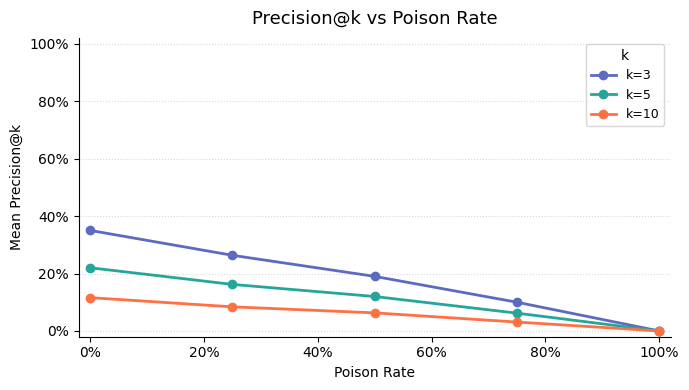

Saved → figures/02_precision_at_k_vs_poison_rate.png


In [5]:
# --- Precision@k vs poison_rate — one line per k ---
K_COLORS = {3: "#5C6BC0", 5: "#26A69A", 10: "#FF7043"}

fig, ax = plt.subplots(figsize=(7, 4))

for k in K_VALUES:
    sub = results[results["k"] == k].sort_values("poison_rate")
    ax.plot(
        sub["poison_rate"], sub["mean_precision_at_k"],
        marker="o", linewidth=2, markersize=6,
        color=K_COLORS[k], label=f"k={k}",
    )

ax.set_title("Precision@k vs Poison Rate", fontsize=13, pad=10)
ax.set_xlabel("Poison Rate")
ax.set_ylabel("Mean Precision@k")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(title="k", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig("../figures/02_precision_at_k_vs_poison_rate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/02_precision_at_k_vs_poison_rate.png")

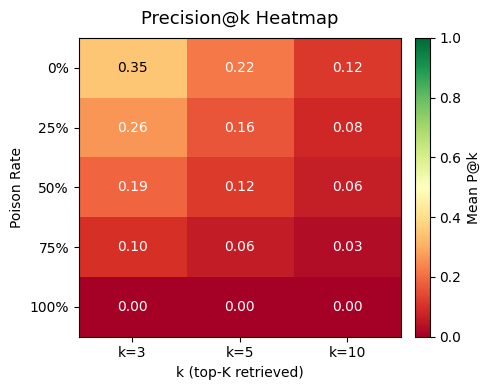

Saved → figures/02_precision_heatmap.png


In [6]:
# --- Heatmap: poison_rate × k ---
pivot = results.pivot(index="poison_rate", columns="k", values="mean_precision_at_k")

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"k={k}" for k in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"{r:.0%}" for r in pivot.index])
ax.set_xlabel("k (top-K retrieved)")
ax.set_ylabel("Poison Rate")
ax.set_title("Precision@k Heatmap", fontsize=13, pad=10)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=10, color="black" if 0.3 < val < 0.85 else "white")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Mean P@k")
plt.tight_layout()
plt.savefig("../figures/02_precision_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/02_precision_heatmap.png")

In [7]:
# --- Summary table ---
table = results.copy()
table["poison_rate"] = table["poison_rate"].map("{:.0%}".format)
table["mean_precision_at_k"] = table["mean_precision_at_k"].map("{:.4f}".format)
table = table.set_index(["poison_rate", "k"])
print(table.to_string())
print("\nKey takeaway: precision@k degrades as poison_rate increases;")
print("larger k amplifies the effect since more slots are available for poisoned passages.")

embedder.close()

               mean_precision_at_k    n
poison_rate k                          
0%          3               0.3500  100
            5               0.2200  100
            10              0.1160  100
25%         3               0.2633  100
            5               0.1620  100
            10              0.0840  100
50%         3               0.1900  100
            5               0.1200  100
            10              0.0630  100
75%         3               0.1000  100
            5               0.0620  100
            10              0.0310  100
100%        3               0.0000  100
            5               0.0000  100
            10              0.0000  100

Key takeaway: precision@k degrades as poison_rate increases;
larger k amplifies the effect since more slots are available for poisoned passages.
